In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install kaggle opencv-python seaborn


In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


In [ ]:
!kaggle datasets list


ref                                                            title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saidaminsaidaxmadov/chocolate-sales                            Chocolate Sales                                    468320  2026-01-04 14:23:35.490000          15222        272  1.0              
aliiihussain/amazon-sales-dataset                              Amazon_Sales_Dataset                              1297759  2026-02-01 11:37:12.353000           2494         51  1.0              
syedaeman2212/global-cars-data                                 Global Cars                                          5889  2026-02-04 19:01:28.920000            618         26  1.0              
vishardmehta/gold-price-foreca

In [ ]:
!kaggle datasets download -d ayushmandatta1/deepdetect-2025


Dataset URL: https://www.kaggle.com/datasets/ayushmandatta1/deepdetect-2025
License(s): apache-2.0
100% 3.23G/3.23G [00:33<00:00, 112MB/s] 
100% 3.23G/3.23G [00:33<00:00, 104MB/s]


In [ ]:
!unzip deepdetect-2025.zip -d deepfake_dataset


Streaming output truncated to the last 5000 lines.
  inflating: deepfake_dataset/ddata/train/real/61451.jpg  
  inflating: deepfake_dataset/ddata/train/real/61453.jpg  
  inflating: deepfake_dataset/ddata/train/real/61455.jpg  
  inflating: deepfake_dataset/ddata/train/real/61456.jpg  
  inflating: deepfake_dataset/ddata/train/real/61458.jpg  
  inflating: deepfake_dataset/ddata/train/real/61459.jpg  
  inflating: deepfake_dataset/ddata/train/real/61460.jpg  
  inflating: deepfake_dataset/ddata/train/real/61461.jpg  
  inflating: deepfake_dataset/ddata/train/real/61464.jpg  
  inflating: deepfake_dataset/ddata/train/real/61465.jpg  
  inflating: deepfake_dataset/ddata/train/real/61466.jpg  
  inflating: deepfake_dataset/ddata/train/real/61467.jpg  
  inflating: deepfake_dataset/ddata/train/real/61468.jpg  
  inflating: deepfake_dataset/ddata/train/real/61469.jpg  
  inflating: deepfake_dataset/ddata/train/real/61470.jpg  
  inflating: deepfake_dataset/ddata/train/real/61472.jpg  
  inf

In [ ]:
import os

base_path = "deepfake_dataset"

for folder in os.listdir(base_path):
    print(folder)


ddata


In [ ]:
os.listdir("deepfake_dataset/ddata")


['train', 'test']

In [ ]:
BASE_DIR = "deepfake_dataset/ddata"

TRAIN_DIR = BASE_DIR + "/train"
TEST_DIR  = BASE_DIR + "/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)


Train path: deepfake_dataset/ddata/train
Test path: deepfake_dataset/ddata/test


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,            # normalize pixels
    rotation_range=20,         # rotate images
    width_shift_range=0.2,     # shift width
    height_shift_range=0.2,    # shift height
    zoom_range=0.2,            # zoom in/out
    horizontal_flip=True       # mirror images
)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Test / Validation data generator (NO augmentation)
test_datagen = ImageDataGenerator(
    rescale=1./255
)


In [ ]:
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 21776 images belonging to 2 classes.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 90409 images belonging to 2 classes.
Found 21776 images belonging to 2 classes.


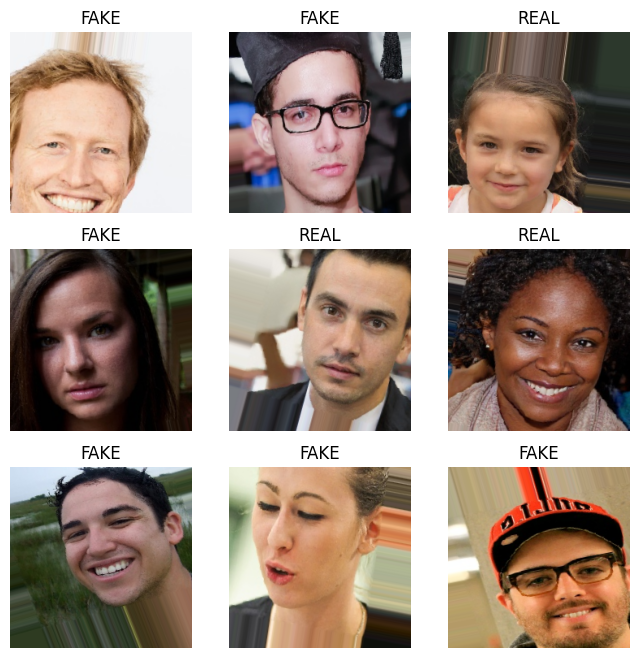

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title("REAL" if labels[i] == 0 else "FAKE")
    plt.axis("off")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',      # pretrained weights
    include_top=False,       # remove original classifier
    input_shape=(224, 224, 3)
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 5   # keep low for now

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 1306s 456ms/step - accuracy: 0.6528 - loss: 0.6263 - val_accuracy: 0.8189 - val_loss: 0.4381
Epoch 2/5
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 1198s 424ms/step - accuracy: 0.7287 - loss: 0.5373 - val_accuracy: 0.8124 - val_loss: 0.4330
Epoch 3/5
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 1205s 427ms/step - accuracy: 0.7446 - loss: 0.5182 - val_accuracy: 0.8114 - val_loss: 0.4338
Epoch 4/5
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 1202s 425ms/step - accuracy: 0.7536 - loss: 0.5055 - val_accuracy: 0.7643 - val_loss: 0.4923
Epoch 5/5
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 1219s 431ms/step - accuracy: 0.7595 - loss: 0.4944 - val_accuracy: 0.8021 - val_loss: 0.4417


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


681/681 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.7581 - loss: 0.5153
Test Accuracy: 0.8020756840705872


In [ ]:
model.save("deepfake_mobilenetv2.h5")
print("Deepfake model saved successfully!")


Deepfake model saved successfully!
